# Random Forest

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,classification_report,confusion_matrix
from sklearn.tree import plot_tree

In [7]:
titanic=sns.load_dataset("titanic")
titanic.head()
features=["pclass","sex","fare","embarked","age"]
target=["survived"]

# Missing data
from sklearn.impute import SimpleImputer

imp_mean=SimpleImputer(strategy="mean")
titanic[["age"]]= imp_mean.fit_transform(titanic[["age"]])
imp_freq=SimpleImputer(strategy="most_frequent")
titanic[["embarked"]]=imp_freq.fit_transform(titanic[["embarked"]])

# Encoding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
titanic["sex"]=le.fit_transform(titanic["sex"])
titanic["embarked"]=le.fit_transform(titanic["embarked"])

X=titanic[features]
y=titanic[target]


X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42)

In [11]:
from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
y_pred_train=model.predict(X_train)

from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,classification_report,confusion_matrix
print("accuracy_score",accuracy_score(y_train,y_pred_train))
print("accuracy_score",accuracy_score(y_test,y_pred))
# this is classic case of overfitting




accuracy_score 0.9791332263242376
accuracy_score 0.7574626865671642


[Text(0.3153672756109023, 0.975, 'sex <= 0.5\ngini = 0.467\nsamples = 623\nvalue = [392, 231]\nclass = Died'),
 Text(0.131343984962406, 0.925, 'pclass <= 2.5\ngini = 0.396\nsamples = 213\nvalue = [58, 155]\nclass = Survived'),
 Text(0.22335563028665414, 0.95, 'True  '),
 Text(0.03571428571428571, 0.875, 'age <= 2.5\ngini = 0.07\nsamples = 110\nvalue = [4, 106]\nclass = Survived'),
 Text(0.015037593984962405, 0.825, 'fare <= 88.775\ngini = 0.5\nsamples = 2\nvalue = [1, 1]\nclass = Died'),
 Text(0.007518796992481203, 0.775, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = Survived'),
 Text(0.022556390977443608, 0.775, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = Died'),
 Text(0.05639097744360902, 0.825, 'fare <= 149.035\ngini = 0.054\nsamples = 108\nvalue = [3, 105]\nclass = Survived'),
 Text(0.03759398496240601, 0.775, 'age <= 49.5\ngini = 0.041\nsamples = 96\nvalue = [2, 94]\nclass = Survived'),
 Text(0.022556390977443608, 0.725, 'fare <= 22.0\ngini = 0.024\nsamples = 84\nvalue =

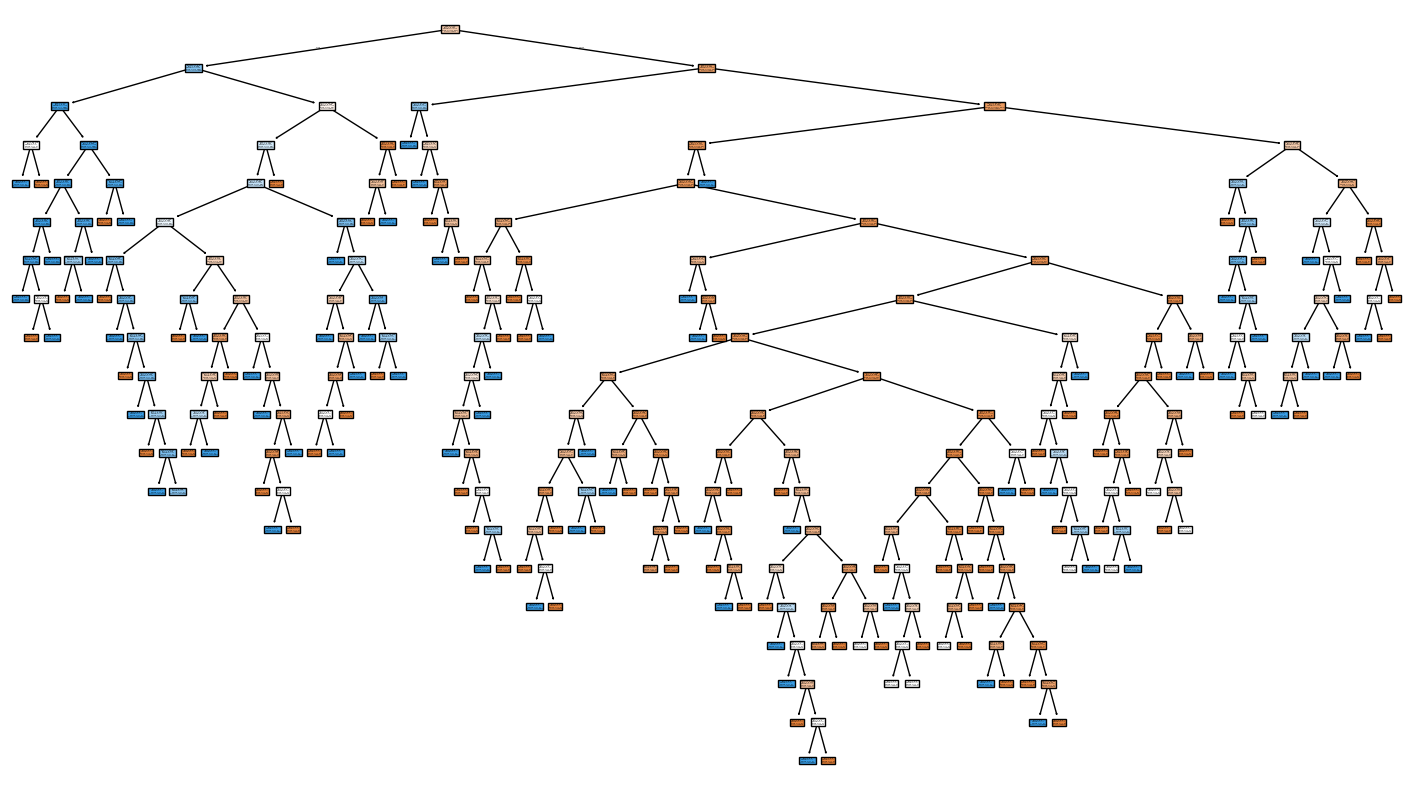

In [12]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True
)

## Apply Random Forest